In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw8.ipynb")

# Homework 8: Nearest Neighbors Regression 🏘

### Collaborators and Sources
In addition to recording your **collaborators** (TAs, peers, group members, roommates, etc.) on this homework in the cell below, you are required to **cite/indicate all external sources** used when finishing this assignment. 
External sources are defined as anything that is not considered course material, such as online sources (webpages, blog posts, etc.), content generated by AI systems, books, etc.

When using external sources, indicate what kind of external sources (e.g. stack overflow, WashU chatGPT, etc.) you used in the cell below and then provide more specific citations (such as links to webpages or in case of AI generated asnwers the actual sources (links provided by the AI system) and the prompt used to generate the answers) with your answer to **each specific problem**.  


Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process, **especially** when two or more submissions closely resemble each other. Working with each other is ok, as long as you cite who you worked with and you don't copy anyone's answers directly!

### Submission instructions
* Submit this Python notebook on Gradescope.
* Execute all cells and save your notebook prior to submission. 
* Don't forget to commit and push to your Github repo!
* **Do not change the number of cells!** Your submission notebook should have exactly one code cell per problem. 
* Do **not** remove the `# your code here` line. Add your solution **after** that line.

### Complete this week's Lab first!
This hw assignment is a continuation of this week's lab. We expect you to **review and complete** the lab prior to doing this hw assignemnt. If you did not get to complete the lab in-class, we expect you to **finish it now**. Almost all parts and specifically the ones towards the end are **highly relevant for and connected to this assignment**. _Parts labeled **Optional** are for the interested student._ 

## Let's get started

In this homework, we will be exploring a more realistic application of similarity-based leanring. Review and complete **Lab 8: Similarity-based Prediction with k-NN** first. Most of the things we ask you to do in this homework are explained in the lab. In general, you should feel free to import any package that we have previously used in class. Ensure that all plots have all of the necessary components that a plot should have (e.g. axes labels, a title, a legend).

### Learning Goals
* **[G8-1]** Understand the **k-nearest neighbor model**.
* **[G8-4]** Understand how **cross-validation** works and know its benefits and shortcomings.
* **[G8-6]** Implement and explore the **k-NN algorithm**.
* **[G8-7]** Implement **feature normalization** and **standardization**.
* **[G8-9]** Implement and use **cross-validation** to select k (hyperparameter / model selection).
#### Practice Python skills
* efficient vector programming using `numpy`
* use `sklearn` for ML

## 1. Using `sklearn` for $k$-Nearest Neighbors

In Lab 8, we got familiar with $k$-nearest neighbors ($k$-NN) by implementing the algorithm. If you are still not comfortable with how the algorithm works, then we suggest that you review your work from the lab. In this home work, we will proceed under the assumption that you are familiar with $k$-NN.

In this assignment, we will explore how to use `sklearn`'s [$k$-NN _regression_ model](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor). Note that there is also a [$k$-NN _classification_ model](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier).

### Loading and Preparing the Data

We'll need to start by getting some data — what is data science without data? For this assignment, we'll check out the [California housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset). It's similar to the Boston housing prices dataset, without the ethical issues (cf. `Lab3`/`hw3`).

In [2]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X, y = california.data, california.target

While we're here, let's check out what this dataset is about.

In [3]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

<!-- BEGIN QUESTION -->

### Problem 1.1

**Write-up!** How many examples are in the dataset? How many features does it have? What are the features? What is the target variable that we would like to estimate/predict? What kind of machine learning problem is this?

There are 20,640 examples in the dataset.

It has 8 features.

The 8 features are:
MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude.

The target variable to be predicted is the median house value, which is the median house price (expressed in $100,000 units) for each region of California.

This is a regression problem in supervised learning because we are predicting a continuous value.

<!-- END QUESTION -->

### Scaling Data

In the lab, we also looked at data standardization and normalization. Here we'll demonstrate how to use `sklearn` to help us with this.

**Approach 1:** 

In [4]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# new train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=8)

# compute the mean and standard deviation on a training set 
scaler = preprocessing.StandardScaler().fit(X_train)

# apply the transforamtion to both the training and the test set
X_train = scaler.transform(X_train)  
X_test = scaler.transform(X_test)  

**Approach 2:** 
An alternative and much quicker way of scaling the the data is the following.

In [5]:
X_scaled = preprocessing.scale(X)

<!-- BEGIN QUESTION -->

### Problem 1.2

**Write-up** Answer all of the following questions: 
- What types of scaling does `StandardScaler()` and `scale` perform?
- Which of the two procedures is a more appropriate preprocessing step for supervised machine learning?
- And _why_?
   
> **Hint:** Use the [`?` operator](https://ipython.readthedocs.io/en/stable/interactive/python-ipython-diff.html#accessing-help) to get more information about the two scaling methods. 

StandardScaler() and scale() both do standardization, which is to make the data roughly have a mean of 0 and a standard deviation of 1.
In supervised learning, Approach 1 is more appropriate.
Because Approach 1 only uses the training set to compute the mean and standard deviation, and then applies the same transformations to the test set, it doesn't leak information from the test set into the model in advance.
Approach 2, on the other hand, directly scales the whole X, which will result in data leakage, so it is not suitable as a preprocessing step for supervised learning.

<!-- END QUESTION -->

### Looking Into the Model

Now that we have some data to play with, let's try building a $k$-NN regression model. The model provided by `sklearn` shares a similar interface with the other models that we have looked at previously (especially $k$-means).

In [6]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)

### Problem 1.3

Use the [`?` operator](https://ipython.readthedocs.io/en/stable/interactive/python-ipython-diff.html#accessing-help) provided by IPython to explore `model` and it's interface.

**Do this!** In the cell below, complete the following:
1. create and fit a new `KNeighborsRegressor` model with `5` neighbors.
2. make some predictions using the model on your testing data.
3. evaluate the performance of the model by computing $R^2$ and storing it in `r_squared`.
4. remove the ? operator after you're done looking at the documentation to prevent the grader from throwing errors.

*Note: this question has hidden tests, or is graded on style of code and not just answer alone.*

In [7]:
import numpy as np

model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)

y_hat = model.predict(X_test)

r_squared = model.score(X_test, y_test)

r_squared

0.6756949840213902

In [8]:
grader.check("q1c")

q1c results: All test cases passed!

<!-- BEGIN QUESTION -->

### Problem 1.4

**Write-up!** What was the $R^2$ value for your k-NN model using five neighbors? What does $R^2$ tell you about a model (in general)? What does your particular $R^2$ score tell you about your k-NN model for this particular application?

R^2≈0.676

(R^2) indicates how much of the variation in the target variable is explained by the model, the closer to 1 the better.

Here (R^2=0.676) indicates that the k-NN model can explain about 67.6% of the change in house prices, which is not bad, but there is still room for improvement.

<!-- END QUESTION -->

With that, let's move on to some more interesting things.

## 2. Cross-Validation Recap & `sklearn` Demo

In order to test whether the `k-NN` algorithm (or any other machine learning algorithm) accurately makes predictions, we must compare the known label of all datapoints to the predicted label of those same datapoints. So far we have seen this in the forms of **model evaluation** using the `test set` set and **model selection** using the `validation set`. 

#### Model Evaluation (and Benchmarking)
In model evaluation we partitioned our original dataset into two parts: a training set and a testing set. As we have seen earlier in the course, the testing set is a smaller percentage of the total dataset than the training set.

#### Model Selection
Later on, in model selection, we explored why it was important to have yet another set of data partitioned out for usage as a validation set, which we could use to experiment with and pick a model's _hyperparameter(s)_ (value(s) that control(s) the learning process). The validation set allows us to "evaluate" our model's performance with various settings of its parameters while maintaining a completely untouched dataset for our final evaluation.

We can extend both processes to improve our estimates of model performance using **cross validation**.

### Cross-validataion: `kFolds` method

> **CAUTION:** It is a total coincidence that for cross-validation the number of partitions, also called folds, are typically numbered with the variable $k$. **This** $k$ **as in "k-fold cross-validation" has nothing to do with the** $k$ **in k-NN!**

The kFolds version of cross validation partitions the dataset into `k` partitions, or folds. We use `k-1` folds to train the model and one fold (the fold we left out) to test or validate the model. We iterate this process `k` times, leaving out a different fold each time, so that we have an accuracy score for each one of the `k` different partitions. We can then take the average of all of these accuracies to calculate a more wholistic accuracy representation of the algorithm. In the example below, `k = 5`; there are 5 partitions. Each partition is used once as a test (or validation) partition while the other 4 are used for training purposes. The idea for $k$-fold cross validation is based on the realization that we can get a better picture of our model's performance by feeding it different combinations of our data.

![](utility/pics/kFold.png)

We use the [`KFold`🔗](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) function from `sklearn`to partition our dataset into `n_splits` partitions. While the `KFold` function does not split the dataset itself, it provides the **indices** on which to split the dataset.

Below, we split an random array of length 10 into 5 folds:

In [9]:
from sklearn.model_selection import KFold

dummy = np.random.randint(10, 100, size = 10) # example data
print(f'data: {dummy}')

# initialize KFolds
kf = KFold(n_splits=5, shuffle=True)

# iterating over k different splits of dummy
for fold, (train_idx, test_idx) in enumerate(kf.split(dummy)):
    print(f'For iteration {fold}: Train indices: {train_idx}. Test indices: {test_idx}')

data: [37 25 27 87 17 59 90 72 43 77]
For iteration 0: Train indices: [1 2 3 4 5 6 7 8]. Test indices: [0 9]
For iteration 1: Train indices: [0 1 2 3 4 5 7 9]. Test indices: [6 8]
For iteration 2: Train indices: [0 2 3 4 5 6 8 9]. Test indices: [1 7]
For iteration 3: Train indices: [0 1 2 3 6 7 8 9]. Test indices: [4 5]
For iteration 4: Train indices: [0 1 4 5 6 7 8 9]. Test indices: [2 3]


Notice how each testing datapoint appears once, ensuring that all datapoints have had a chance to be be tested against the model trained with the rest of the dataset. 

### Model Selection: Choosing $k$ with Cross Validation

Now, let's use the `KFold` operation on the training set of California Housing dataset spliting it into _training_ and _validation_ portions. We'll start by replicating the training and testing sets from the previous section.

In [10]:
# recreate train-test split (from the raw (unscaled) data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=8)

### Problem 2.1

**Do this!** Complete the `knn_kfolds` function so that it performs `n_folds`-fold cross validation on the dataset `X` and applies $k$-NN regression with k=`n_neighbors` nearest neighbors. The function should return the average $R^2$ value of the model across the folds as `avg_score`.

* Make sure to **scale** your training and validation sets in each fold appropriately (à la the [Scaling Data](#Scaling-Data) section).
* Ensure that you make and **fit a new model** for each fold.
* Also, please make sure that you set `random_state` appropriately in your initialization of `KFold`.

>**Hint**: Refer to the previous example of how to use `KFold` and your work in [Problem 1.2](#Problem-1.2).

In [11]:
def knn_kfolds(X, y, n_folds, n_neighbors, random_state=None):
    from sklearn.model_selection import KFold
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.preprocessing import StandardScaler
    import numpy as np

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]
        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        model = KNeighborsRegressor(n_neighbors=n_neighbors)
        model.fit(X_train_fold, y_train_fold)

        scores.append(model.score(X_val_fold, y_val_fold))

    avg_score = np.mean(scores)
    return avg_score

In [12]:
grader.check("q2a")

q2a results: All test cases passed!

<!-- BEGIN QUESTION -->

### Problem 2.2

In this problem, we will use cross validation and our `knn_kfolds` function to help us pick the right $k$ to use for our California Housing predictions.

**Do this!** In the following cell, use `knn_kfolds()` to preform 10-fold cross validation on `X_train` and `y_train` to evaluate the performance of $k$-NN on the California Housing dataset and provide a plot of the cross validation average $R^2$ values for nearest neighbor values `k` from 1 to 20 (inclusive). Use a `random_state` of 12 for your analysis. Ensure that your plot has all of the appropriate components.

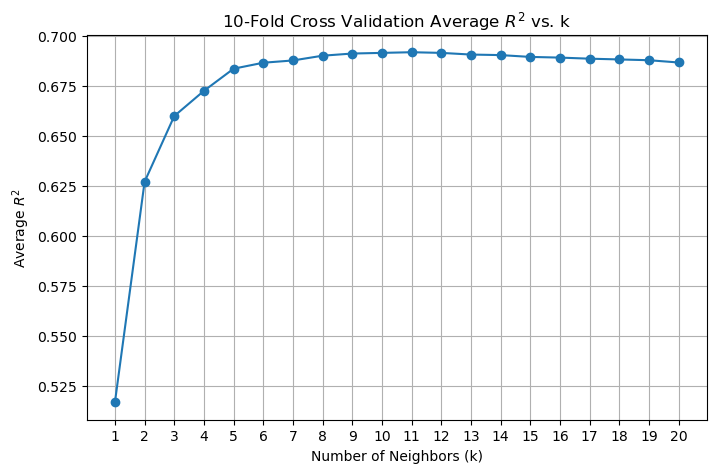

In [13]:
import matplotlib.pyplot as plt

k_values = list(range(1, 21))
avg_r2_scores = []

for k in k_values:
    score = knn_kfolds(X_train, y_train, 10, k, random_state=12)
    avg_r2_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, avg_r2_scores, marker='o')
plt.title('10-Fold Cross Validation Average $R^2$ vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average $R^2$')
plt.xticks(k_values)
plt.grid(True)
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 2.3

**Write-up!** Based on your plot from [Problem 2.2](#Problem-2.2), which $k$ value would you pick for your final model? Explain why. Argue whether your choice is clear cut or if there migth very well be other reasonable values for $k$. 

I would choose (k=11) because it gives the highest or near highest average (R^2) value on the graph.

However, this choice is not completely absolute, as the performance from about (k=8) to (k=14) is very close, so these are reasonable choices as well.

This suggests that the model is stable over this range, rather than that one (k) is clearly the best.

<!-- END QUESTION -->

## 3. Model Evaluation and Benchmarking

As mentioned before, we can use cross validation to get a more thorough evaluation of model performance. Now, we will use **CV for model evaluation**. We will use the same `knn_kfolds()` implementation that you created for the model selection process above. Note that the approach below is actually not quite legal, since we will not re-learn $k$ on the repective training splits used in evaluation (_which we really should be doing_). However, this would lead to a _nested cross-validation_ which is a little too advanced for this hw assignment.

Now, we will evaluate our $k$-NN regression model using cross-validation and compare it with a benchmark model -  a linear regression model.

### Problem 3.1

Let's see how the model you selected above performs on the test set.

**Do This:** Train a $k$-NN model using the $k$ you selected in [Problem 2.3](#Problem-2.3) on the __entire__ training set and evaluate it on the __untouched__ test set.

In [14]:
# compute the mean and standard deviation on a training set 
scaler = preprocessing.StandardScaler().fit(X_train)

# apply the transforamtion to both the trainnig and the test set
X_train = scaler.transform(X_train)  
X_test = scaler.transform(X_test)  

k = 11
model = KNeighborsRegressor(n_neighbors=k)

model.fit(X_train, y_train)

y_hat = model.predict(X_test)

r_squared = model.score(X_test, y_test)

r_squared

0.6789134214374379

In [15]:
grader.check("q3a")

q3a results: All test cases passed!

As mentioned before, we can use cross validation to get a more thorough evaluation of model performance. Now, we will use CV for model comparison by substituting it in for the model selection process that we have used in above. Note that the approach below is actually not quite legal, since we will not re-learn $k$ on the repective training splits (which we should be doing). This would lead to a _nested cross-validation_ which is a little too advanced for this hw assignment.

Now, we will evaluate our $k$-NN regression model using cross-validation and compate it with a linear regression model.

### Problem 3.2

**Do this!** In the following cell, report the cross validation score (average $R^2$) of a $k$-NN model on the entirety of `X` with the $k$ you selected in [Problem 2.3](#Problem-2.3). Use `random_state = 5` and `n_folds = 10` folds.

*Note: this question has hidden tests, or is graded on style of code and not just answer alone.*

In [16]:
k = 11
n_folds = 10
cross_val_score = knn_kfolds(X, y, n_folds, k, random_state=5)
cross_val_score

np.float64(0.701535563058289)

In [17]:
grader.check("q3b")

q3b results: All test cases passed!

<!-- BEGIN QUESTION -->

### Problem 3.3

Now let's do 10-fold cross validation on a linear regression model on `X` _without scaling_.

**Write-up** Why do we not need to scale our features here? What will happen if we did?

Scaling is not necessarily needed here because linear regression does not rely on distance calculations as much as k-NN does, so differences in the magnitude of the features usually do not directly affect the way it predicts.

If scaling is done, the predictions of the model and (R^2) will generally not change significantly, only the values of the coefficients will change and become easier to compare.

<!-- END QUESTION -->

**Do this!** Perform 10-fold cross validation for linear regression on `X` and report the average $R^2$ value across all of the folds. Store your $R^2$ values for each fold in `scores`.

* Ensure that you make and **fit a new model** for each fold.
* Use the same random state as we used to evaluate k-NN, so that the cross-validation splits stay the **same**. 
* Be careful not to override variables such as `X_train`, `X_test`, `y_train`, `y_test`.

> **Hint:** Refer to your work in [Problem 2.1](#Problem-2.1) and [Problem 3.1](#Problem-3.1).

*Note: this question has hidden tests, or is graded on style of code and not just answer alone.*

In [18]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import numpy as np

scores = []

kf = KFold(n_splits=10, shuffle=True, random_state=5)

for train_idx, test_idx in kf.split(X):
    X_train_fold = X[train_idx]
    X_test_fold = X[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]
    
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)
    
    score = model.score(X_test_fold, y_test_fold)
    scores.append(score)

avg_score = np.mean(scores)
avg_score

np.float64(0.6036174923131291)

In [19]:
grader.check("q3cii")

q3cii results: All test cases passed!

<!-- BEGIN QUESTION -->

### Problem 3.4

**Write-up!** What were the average $R^2$ values for the $k$-NN and linear regression models? Which model perfroms better? Why do you think the better performing model performs better? **Discuss.**

The average (R^2) for the k-NN model is about 0.702, and the average (R^2) for the linear regression model is about 0.604.
So k-NN performs better because it has a higher (R^2), which means it explains more of the change in house prices.
The reason I think k-NN is better is that the relationship between house prices in this data may not be a simple linear relationship, and k-NN is better at capturing localized and non-linear patterns; linear regression can only fit an overall straight line relationship, and is therefore less effective.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## 4. Next Steps: Cirtical Review and Deployment

### Problem 4.1

**Write-up!** You've decided to use the KNN model to predict home prices in California! What are your next steps as a data scientist? Describe two things (related to the DS workflow of this project).

Next, I would first continue testing with the selected k-NN model on new or really unseen data to confirm that it is performing consistently and not just valid for the current data.
Then, I will continue to improve the model and features, such as trying different feature engineering, checking for areas of high error, or comparing other models to see if I can further improve the house price prediction.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 4.2

**Write-up!** [**critical review**] It looks like we used a pretty solid process to evalaute and compare the two models. But hold on, something went wrong. Go back and carefully look things over again. By doing so you will notice a crude instance of _data snooping_! Find it and carefully describe what we did wrong. Finally, outline a better process to compare the two models **avoiding data snooping** (there is more than one valid solution here; we only ask you to describe one). 

The problem is that we first do a model selection with the same data, select the best (k), and then use the same set of selected parameters to do the evaluation later. This is a kind of data snooping / information leakage as the evaluation process sees the data indirectly.

More specifically, when we pick (k) with the cross-validation results and report the performance of the model, we do not separate the “picking (k)” step from the “final evaluation”, so the final score will be a bit too optimistic.

A better approach would be to split the data into a training set and a test set; then use cross-validation to select the best (k) only on the training set; after selecting the best (k), retrain the model on the whole training set, and then do the final comparison only on the test set which has not been involved in the selection of the model at all.

A more rigorous approach is to use nested cross-validation, which completely separates “parameter selection” from “model evaluation”.

<!-- END QUESTION -->

**That's it! Follow the submission instructions below:**
* Restart your kernel and run all the cells
* Save your notebook
* Upload the .ipynb notebook directly to Gradescope